
 line_profiler: mandelbrot (naive Python) 

Timer unit: 1e-09 s

Total time: 12.1121 s
File: /Users/niklasandersen/Documents/GitHub/NSC-mandelbrot/mandelbrot.py
Function: mandelbrot_naive at line 61

Line #      Hits         Time  Per Hit   % Time  Line Contents
    61                                           def mandelbrot_naive(width, height, max_iter, xmin, xmax, ymin, ymax):
    62         1    4090000.0 4.09e+06      0.0      img = [[0] * width for _ in range(height)]
    63                                           
    64      1025     235000.0    229.3      0.0      for y in range(height):
    65      1024     208000.0    203.1      0.0          im = ymin + (y / (height - 1)) * (ymax - ymin)
    66                                           
    67   1049600  151792000.0    144.6      1.3          for x in range(width):
    68   1048576  189651000.0    180.9      1.6              re = xmin + (x / (width - 1)) * (xmax - xmin)
    69   1048576  209564000.0    199.9      1.7     

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.



 cProfile: mandelbrot (Numba, warmed up) (sorted by cumulative) 

         2 function calls in 0.000 seconds

   Ordered by: cumulative time

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        1    0.000    0.000    0.000    0.000 {method 'disable' of '_lsprof.Profiler' objects}
        1    0.000    0.000    0.000    0.000 serialize.py:30(_numba_unpickle)



mandelbrot (Numba, warmed up): 0.018192 s


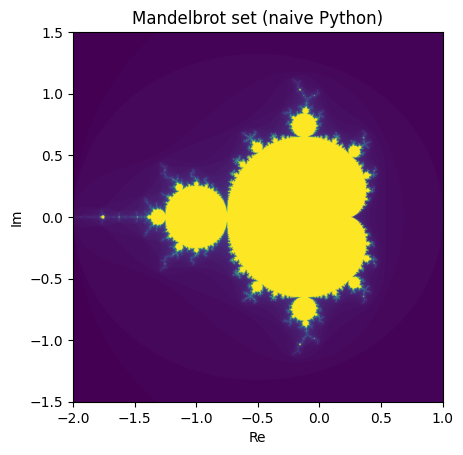

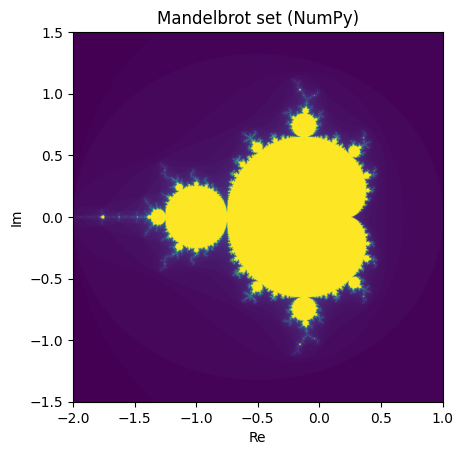

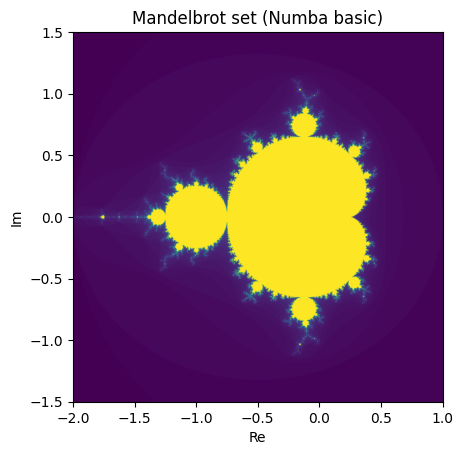

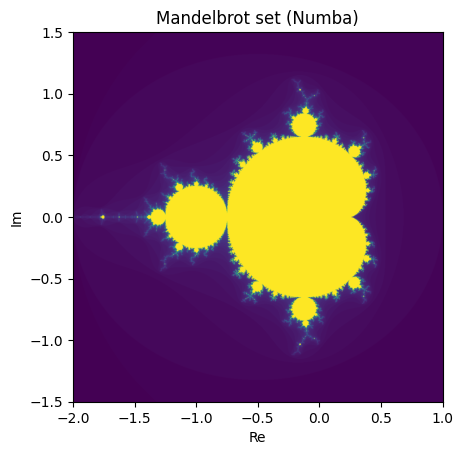

In [1]:
import time
import numpy as np

from mandelbrot import (
    mandelbrot_naive,
    mandelbrot_numpy,
    mandelbrot_numba,
    mandelbrot_numba_basic,
)

In [2]:
grid_sizes = [1024] #[256, 512, 1024, 2048, 4096]

max_iter = 100
xmin, xmax = -2.0, 1.0
ymin, ymax = -1.5, 1.5

In [3]:
def best_of_5(func, *args):
    times = []
    result = None
    for _ in range(5):
        t0 = time.perf_counter()
        result = func(*args)
        t1 = time.perf_counter()
        times.append(t1 - t0)
    return min(times), result

def checksum(out):
    if isinstance(out, list):
        return sum(sum(row) for row in out)
    return int(np.sum(out))

In [ ]:
implementations = [
    ("naive", mandelbrot_naive),
    ("numpy", mandelbrot_numpy),
    ("numba_basic_f64", lambda w,h,mi,x0,x1,y0,y1: mandelbrot_numba_basic(w,h,mi,x0,x1,y0,y1, dtype=np.float64)),
    ("numba_basic_f32", lambda w,h,mi,x0,x1,y0,y1: mandelbrot_numba_basic(w,h,mi,x0,x1,y0,y1, dtype=np.float32)),
    ("numba", mandelbrot_numba),
]

# Warm up numba kernels (avoid counting compilation time)
warm_args = (256, 256, max_iter, xmin, xmax, ymin, ymax)
mandelbrot_numba(*warm_args)
mandelbrot_numba_basic(*warm_args)  # float64 default
mandelbrot_numba_basic(*warm_args, dtype=np.float32)

In [5]:
print(f"{'grid':>5}  {'implementation':<14}  {'best_of_5 (s)':>14}  {'speedup_vs_naive':>16}  {'checksum':>12}")
print("-" * 76)

for n in grid_sizes:
    width = height = n
    args = (width, height, max_iter, xmin, xmax, ymin, ymax)

    naive_time, naive_out = best_of_5(mandelbrot_naive, *args)
    naive_chk = checksum(naive_out)

    print(f"{n:>5}  {'naive':<14}  {naive_time:>14.6f}  {1.0:>16.2f}  {naive_chk:>12}")

    for name, fn in implementations[1:]:
        tbest, out = best_of_5(fn, *args)
        chk = checksum(out)
        speedup = naive_time / tbest
        print(f"{n:>5}  {name:<14}  {tbest:>14.6f}  {speedup:>16.2f}  {chk:>12}")

    print("-" * 76)

 grid  implementation   best_of_5 (s)  speedup_vs_naive      checksum
----------------------------------------------------------------------------
 1024  naive                 2.932989              1.00      21959734
 1024  numpy                 0.585843              5.01      21959734
 1024  numba_basic_f64        0.050847             57.68      21959734
 1024  numba_basic_f32        0.050826             57.71      21959734
 1024  numba                 0.017213            170.39      21959734
----------------------------------------------------------------------------
